# 🍎 Reentrenamiento y Evaluación: EfficientNet-B0 — fruit-og-4

Este notebook **reentrena desde cero** un clasificador de frutas usando EfficientNet-B0 con el dataset `tonyss911/fruit-og-4`, y luego lo evalúa sobre el split `test`.

| Parámetro | Valor |
|---|---|
| **Arquitectura** | EfficientNet-B0 (backbone ImageNet + fine-tuning completo) |
| **Dataset** | `tonyss911/fruit-og-4`  |
| **Estrategia** | Phase 1: entrenar solo cabeza (5 épocas) → Phase 2: fine-tuning completo (10 épocas) |
| **Dispositivo** | CUDA (recomendado) / CPU |

> ⚠️ **Requiere GPU.** En Google Colab: `Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU (T4)`.

## 1. Instalación de dependencias

In [ ]:
!pip install torch torchvision huggingface_hub datasets Pillow scikit-learn matplotlib seaborn tqdm pyarrow -q
print('✅ Dependencias instaladas.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 62.6 MB/s eta 0:00:00
✅ Dependencias instaladas.


## 2. Imports y dispositivo

In [ ]:
import os, re, json, copy, time
import numpy as np
import pandas as pd
from io import BytesIO
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image as PILImage
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset as TorchDataset
import torchvision.models as models
from torchvision import transforms

from datasets import (
    Dataset, Features, ClassLabel,
    Image as HFImage, load_dataset_builder, load_dataset
)
from huggingface_hub import hf_hub_download
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, top_k_accuracy_score,
    f1_score, precision_score, recall_score
)
from tqdm.auto import tqdm

print(f'PyTorch     : {torch.__version__}')
print(f'CUDA        : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo : {DEVICE}')

PyTorch     : 2.6.0+cu124
CUDA        : True
GPU         : Tesla T4
Dispositivo : cuda


## 3. Configuración global

In [ ]:
# ── Rutas locales (parquet subidos a Colab) ──────────────────────────────────
TRAIN_PARQUET = '/content/train-pogg.parquet'   # Opcional: si tienes el archivo local
TEST_PARQUET  = '/content/test-bogg.parquet'    # Opcional: si tienes el archivo local
HF_DATASET_ID = 'tonyss911/fruit-og-4' # Fuente HuggingFace (fallback automático)

# ── Hiperparámetros ──────────────────────────────────────────────────────────
IMG_SIZE      = 224
BATCH_SIZE    = 64
NUM_WORKERS   = 2

# Phase 1: solo cabeza clasificadora
EPOCHS_HEAD   = 5
LR_HEAD       = 1e-3

# Phase 2: fine-tuning completo del backbone
EPOCHS_FULL   = 5
LR_FULL       = 1e-4
LR_BACKBONE   = 1e-5   # backbone con LR más bajo

WEIGHT_DECAY  = 1e-4
PATIENCE      = 4       # early stopping
SAVE_PATH     = '/content/best_model.pth'

# ── Seed reproducible ───────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print('Configuración lista.')

Configuración lista.


## 4. Carga del dataset

Carga desde archivo local si existe, sino descarga desde HuggingFace Hub.

In [ ]:
# ── Obtener nombres de clases sin descargar el dataset completo ─────────────
print(f'Obteniendo metadatos de {HF_DATASET_ID}...')
builder = load_dataset_builder(HF_DATASET_ID)
all_class_names = builder.info.features['label'].names  # 113 clases originales
print(f'Clases en el dataset original: {len(all_class_names)}')

features_def = Features({
    'image': HFImage(),
    'label': ClassLabel(names=all_class_names)
})

def load_split_from_parquet(path, features):
    """Carga un split desde un archivo parquet local."""
    df = pd.read_parquet(path)
    ds = Dataset.from_pandas(df).cast(features)
    def open_bytes(ex):
        if isinstance(ex['image'], dict) and 'bytes' in ex['image']:
            try:
                ex['image'] = PILImage.open(BytesIO(ex['image']['bytes'])).convert('RGB')
            except Exception:
                ex['image'] = None
        return ex
    ds = ds.map(open_bytes, num_proc=1)
    ds = ds.filter(lambda x: x['image'] is not None)
    ds = ds.cast(Features({'image': HFImage(), 'label': ds.features['label']}))
    return ds

# ── Cargar train ─────────────────────────────────────────────────────────────
if os.path.exists(TRAIN_PARQUET):
    print(f'\nCargando train desde {TRAIN_PARQUET}...')
    train_hf = load_split_from_parquet(TRAIN_PARQUET, features_def)
else:
    print('\nDescargando train desde HuggingFace Hub...')
    train_hf = load_dataset(HF_DATASET_ID, split='train')

# ── Cargar test ──────────────────────────────────────────────────────────────
if os.path.exists(TEST_PARQUET):
    print(f'Cargando test desde {TEST_PARQUET}...')
    test_hf = load_split_from_parquet(TEST_PARQUET, features_def)
else:
    print('Descargando test desde HuggingFace Hub...')
    test_hf = load_dataset(HF_DATASET_ID, split='test')

all_class_names = train_hf.features['label'].names
print(f'\n✅ Train: {len(train_hf):,} muestras')
print(f'✅ Test : {len(test_hf):,} muestras')
print(f'Clases  : {len(all_class_names)}')

Obteniendo metadatos de tonyss911/fruit-og-4...


Clases en el dataset original: 22

Cargando train desde /content/train-pogg.parquet...


Casting the dataset:   0%|          | 0/2367 [00:00<?, ? examples/s]

Map:   0%|          | 0/2367 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2367 [00:00<?, ? examples/s]

...

Casting the dataset:   0%|          | 0/591 [00:00<?, ? examples/s]

Map:   0%|          | 0/591 [00:00<?, ? examples/s]

Filter:   0%|          | 0/591 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/591 [00:00<?, ? examples/s]


✅ Train: 2,367 muestras
✅ Test : 591 muestras
Clases  : 22


## 5. Fusión de clases: 113 → 76

Replicamos la misma lógica del modelo original: fusionar variantes numéricas y de color en una clase genérica.

In [ ]:
def get_base_class(name: str) -> str:
    """Extrae la clase base eliminando variantes numéricas y de color."""
    name = name.strip()
    name = re.sub(r'\s*\(.*?\)', '', name)            # quitar paréntesis
    name = re.sub(r'\s+(Red|Yellow|Green|White|Black|Pink|Golden|Crimson|Dark|Lady|\d+).*$',
                  '', name, flags=re.IGNORECASE)       # quitar descriptores de color/número
    return name.strip()

# Construir las 76 clases fusionadas en el mismo orden que el modelo original
seen = []
orig_to_fused = {}  # nombre_original -> nombre_fusionado
for name in all_class_names:
    base = get_base_class(name)
    orig_to_fused[name] = base
    if base not in seen:
        seen.append(base)

fused_classes = seen  # Lista de 76 clases fusionadas
fused_to_idx  = {c: i for i, c in enumerate(fused_classes)}

# Mapeo de índice original (0-112) → índice fusionado (0-75)
orig_idx_to_fused_idx = {
    i: fused_to_idx[orig_to_fused[name]]
    for i, name in enumerate(all_class_names)
}

NUM_CLASSES = len(fused_classes)
id2label    = {str(i): c for i, c in enumerate(fused_classes)}

print(f'Clases fusionadas: {NUM_CLASSES}')
print(f'Primeras 10: {fused_classes[:10]}')
print(f'\nEjemplos de fusión:')
examples = [(n, orig_to_fused[n]) for n in all_class_names if n != orig_to_fused[n]][:10]
for orig, fused in examples:
    print(f'  {orig:<30} → {fused}')

Clases fusionadas: 22
Primeras 10: ['Apple', 'Avocado', 'Banana', 'Blackberry', 'Blueberry', 'CherryTomato', 'Cucumber', 'Dragon', 'Grape', 'Kiwifruit']

Ejemplos de fusión:


## 6. PyTorch Dataset con augmentación

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class FruitDataset(TorchDataset):
    """Dataset de PyTorch que envuelve un HuggingFace Dataset."""
    def __init__(self, hf_dataset, label_map, transform):
        self.data      = hf_dataset
        self.label_map = label_map   # orig_idx -> fused_idx
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ex    = self.data[idx]
        img   = ex['image'].convert('RGB')
        label = self.label_map[ex['label']]
        return self.transform(img), label


train_dataset = FruitDataset(train_hf, orig_idx_to_fused_idx, train_transform)
test_dataset  = FruitDataset(test_hf,  orig_idx_to_fused_idx, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')
print(f'Train augment : RandomCrop, Flips, ColorJitter, Rotation')
print(f'Val transform : Resize + Normalize')

Train batches : 37
Test  batches : 10
Train augment : RandomCrop, Flips, ColorJitter, Rotation
Val transform : Resize + Normalize


## 7. Definición del modelo

EfficientNet-B0 preentrenado en ImageNet con cabeza clasificadora reemplazada.

In [ ]:
def build_model(num_classes: int, freeze_backbone: bool = True):
    """Construye EfficientNet-B0 con cabeza personalizada."""
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    # Reemplazar cabeza clasificadora
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_classes)
    )

    if freeze_backbone:
        # Congelar todo excepto la cabeza
        for name, param in model.named_parameters():
            if 'classifier' not in name:
                param.requires_grad = False

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Parámetros entrenables: {trainable:,} / {total:,} '
          f'({"backbone congelado" if freeze_backbone else "backbone descongelado"})')
    return model


model = build_model(NUM_CLASSES, freeze_backbone=True)
model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 179MB/s]


Parámetros entrenables: 28,182 / 4,035,730 (backbone congelado)


## 8. Funciones de entrenamiento y evaluación

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_true, all_probs = [], [], []
    for imgs, labels in tqdm(loader, desc='  Eval ', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        out   = model(imgs)
        loss  = criterion(out, labels)
        probs = torch.softmax(out, dim=1).cpu().numpy()
        preds = out.argmax(1)
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())
        all_probs.extend(probs)
    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_true), np.array(all_probs))


def run_training(model, train_loader, test_loader, epochs, optimizer, scheduler,
                 criterion, device, phase_name, history=None):
    """Loop de entrenamiento con early stopping y guardado del mejor modelo."""
    if history is None:
        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    best_val_acc  = 0.0
    best_weights  = copy.deepcopy(model.state_dict())
    patience_cnt  = 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc, _, _, _ = eval_epoch(model, test_loader, criterion, device)

        if scheduler is not None:
            scheduler.step(vl_loss)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        elapsed = time.time() - t0
        print(f'[{phase_name}] Época {epoch:02d}/{epochs} | '
              f'Train loss: {tr_loss:.4f} acc: {tr_acc:.4f} | '
              f'Val loss: {vl_loss:.4f} acc: {vl_acc:.4f} | '
              f'{elapsed:.0f}s')

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, SAVE_PATH)
            print(f'  ✅ Nuevo mejor modelo guardado (val_acc={vl_acc:.4f})')
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f'  ⏹ Early stopping en época {epoch}.')
                break

    model.load_state_dict(best_weights)
    print(f'\n  Mejor val_acc en {phase_name}: {best_val_acc:.4f}')
    return model, history


criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
print('Funciones de entrenamiento definidas.')

Funciones de entrenamiento definidas.


## 9. Phase 1: Entrenar solo la cabeza clasificadora

El backbone de EfficientNet-B0 permanece congelado. Solo se actualizan los pesos de la capa final.

In [ ]:
print('=== PHASE 1: Cabeza clasificadora (backbone congelado) ===')
print(f'Épocas: {EPOCHS_HEAD} | LR: {LR_HEAD} | Batch: {BATCH_SIZE}\n')

optimizer_head = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=WEIGHT_DECAY
)
scheduler_head = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_head, mode='min', factor=0.5, patience=2
)

model, history = run_training(
    model, train_loader, test_loader,
    epochs=EPOCHS_HEAD,
    optimizer=optimizer_head,
    scheduler=scheduler_head,
    criterion=criterion,
    device=DEVICE,
    phase_name='Phase1'
)

=== PHASE 1: Cabeza clasificadora (backbone congelado) ===
Épocas: 5 | LR: 0.001 | Batch: 64



  Train:   0%|          | 0/37 [00:00<?, ?it/s]

  Eval :   0%|          | 0/10 [00:00<?, ?it/s]

[Phase1] Época 01/5 | Train loss: 2.4408 acc: 0.4728 | Val loss: 1.8032 acc: 0.7682 | 31s
  ✅ Nuevo mejor modelo guardado (val_acc=0.7682)


  Train:   0%|          | 0/37 [00:00<?, ?it/s]

...

  Eval :   0%|          | 0/10 [00:00<?, ?it/s]

[Phase1] Época 04/5 | Train loss: 1.1438 acc: 0.8771 | Val loss: 1.0493 acc: 0.9086 | 30s
  ✅ Nuevo mejor modelo guardado (val_acc=0.9086)


  Train:   0%|          | 0/37 [00:00<?, ?it/s]

  Eval :   0%|          | 0/10 [00:00<?, ?it/s]

[Phase1] Época 05/5 | Train loss: 1.0827 acc: 0.8893 | Val loss: 1.0017 acc: 0.9222 | 29s
  ✅ Nuevo mejor modelo guardado (val_acc=0.9222)

  Mejor val_acc en Phase1: 0.9222


## 10. Phase 2: Fine-tuning completo del backbone

Se descongela todo el modelo con tasas de aprendizaje diferenciadas: más baja para el backbone (ya preentrenado), más alta para la cabeza.

In [ ]:
print('=== PHASE 2: Fine-tuning completo (backbone descongelado) ===')
print(f'Épocas: {EPOCHS_FULL} | LR cabeza: {LR_FULL} | LR backbone: {LR_BACKBONE}\n')

# Descongelar todo el modelo
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Parámetros entrenables: {trainable:,} / {total:,} (backbone descongelado)')

# LR diferenciado: backbone más lento
backbone_params   = [p for n, p in model.named_parameters() if 'classifier' not in n]
classifier_params = [p for n, p in model.named_parameters() if 'classifier' in n]

optimizer_full = optim.AdamW([
    {'params': backbone_params,   'lr': LR_BACKBONE},
    {'params': classifier_params, 'lr': LR_FULL}
], weight_decay=WEIGHT_DECAY)

scheduler_full = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_full, T_max=EPOCHS_FULL, eta_min=1e-6
)

model, history = run_training(
    model, train_loader, test_loader,
    epochs=EPOCHS_FULL,
    optimizer=optimizer_full,
    scheduler=scheduler_full,
    criterion=criterion,
    device=DEVICE,
    phase_name='Phase2',
    history=history
)

=== PHASE 2: Fine-tuning completo (backbone descongelado) ===
Épocas: 5 | LR cabeza: 0.0001 | LR backbone: 1e-05

Parámetros entrenables: 4,035,730 / 4,035,730 (backbone descongelado)


  Train:   0%|          | 0/37 [00:00<?, ?it/s]

  Eval :   0%|          | 0/10 [00:00<?, ?it/s]

[Phase2] Época 01/5 | Train loss: 1.0257 acc: 0.9096 | Val loss: 0.9712 acc: 0.9255 | 34s
  ✅ Nuevo mejor modelo guardado (val_acc=0.9255)


  Train:   0%|          | 0/37 [00:00<?, ?it/s]

...

  Eval :   0%|          | 0/10 [00:00<?, ?it/s]

[Phase2] Época 04/5 | Train loss: 0.9525 acc: 0.9252 | Val loss: 0.9123 acc: 0.9475 | 32s
  ✅ Nuevo mejor modelo guardado (val_acc=0.9475)


  Train:   0%|          | 0/37 [00:00<?, ?it/s]

  Eval :   0%|          | 0/10 [00:00<?, ?it/s]

[Phase2] Época 05/5 | Train loss: 0.9262 acc: 0.9349 | Val loss: 0.8962 acc: 0.9526 | 32s
  ✅ Nuevo mejor modelo guardado (val_acc=0.9526)

  Mejor val_acc en Phase2: 0.9526


## 11. Curvas de entrenamiento

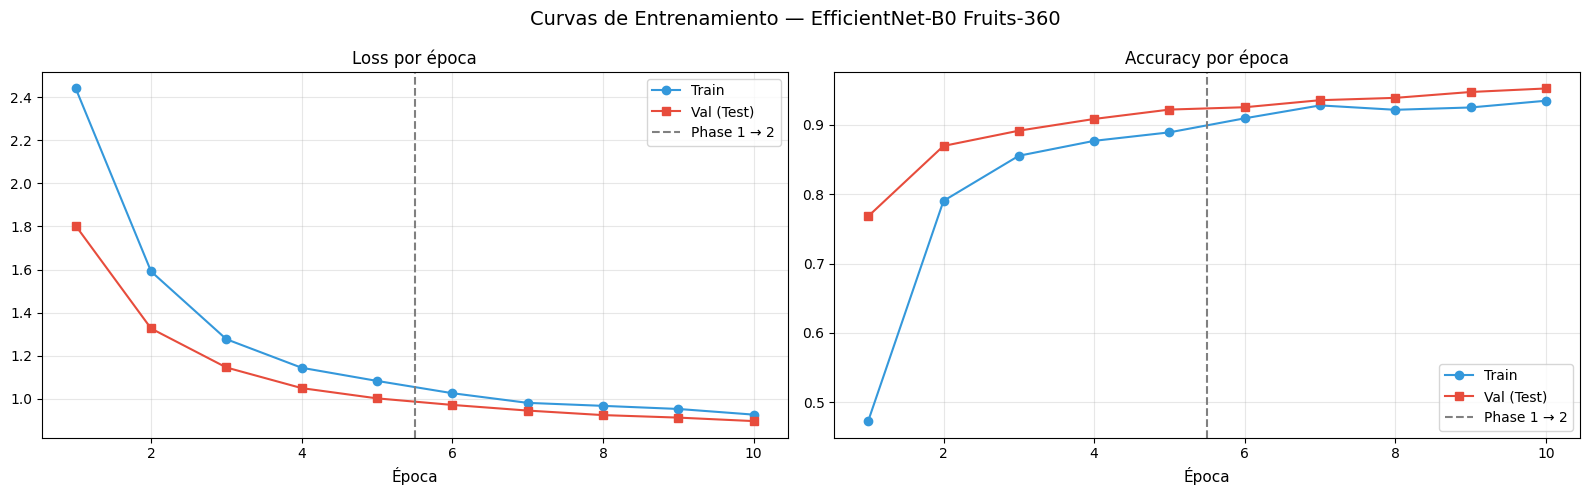

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
epochs_range = range(1, len(history['train_loss']) + 1)
phase1_end   = EPOCHS_HEAD  # línea divisoria entre phases

for ax, metric, title in zip(
    axes,
    [('train_loss', 'val_loss'), ('train_acc', 'val_acc')],
    ['Loss por época', 'Accuracy por época']
):
    train_key, val_key = metric
    ax.plot(epochs_range, history[train_key], 'o-', color='#3498db', label='Train')
    ax.plot(epochs_range, history[val_key],   's-', color='#e74c3c', label='Val (Test)')
    ax.axvline(phase1_end + 0.5, color='gray', linestyle='--', linewidth=1.5,
               label='Phase 1 → 2')
    ax.set_xlabel('Época', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('Curvas de Entrenamiento — EfficientNet-B0 Fruits-360', fontsize=14)
plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Evaluación final en el test set

In [ ]:
print('Ejecutando evaluación final sobre el test set...')
_, _, all_preds, all_true, all_probs = eval_epoch(
    model, test_loader, criterion, DEVICE
)

top1  = accuracy_score(all_true, all_preds)
top5  = top_k_accuracy_score(all_true, all_probs, k=5, labels=list(range(NUM_CLASSES)))
f1    = f1_score(all_true, all_preds, average='weighted', zero_division=0)
prec  = precision_score(all_true, all_preds, average='weighted', zero_division=0)
rec   = recall_score(all_true, all_preds, average='weighted', zero_division=0)
conf_ok  = all_probs.max(axis=1)[all_preds == all_true].mean()
conf_err = all_probs.max(axis=1)[all_preds != all_true].mean()

print('\n' + '=' * 58)
print('          RESULTADOS FINALES — TEST SET')
print('=' * 58)
print(f'  Modelo      : EfficientNet-B0 (fine-tuning completo)')
print(f'  Dataset     : PedroSampaio/fruits-360 (split=test)')
print(f'  Muestras    : {len(all_true):,}')
print(f'  Clases      : {NUM_CLASSES}')
print('-' * 58)
print(f'  Top-1 Accuracy    : {top1 * 100:.2f}%')
print(f'  Top-5 Accuracy    : {top5 * 100:.2f}%')
print(f'  Precision (w-avg) : {prec * 100:.2f}%')
print(f'  Recall    (w-avg) : {rec  * 100:.2f}%')
print(f'  F1-Score  (w-avg) : {f1   * 100:.2f}%')
print('-' * 58)
print(f'  Confianza media (aciertos) : {conf_ok:.4f}')
print(f'  Confianza media (errores)  : {conf_err:.4f}')
print('=' * 58)

Ejecutando evaluación final sobre el test set...


  Eval :   0%|          | 0/10 [00:00<?, ?it/s]


          RESULTADOS FINALES — TEST SET
  Modelo      : EfficientNet-B0 (fine-tuning completo)
  Dataset     : PedroSampaio/fruits-360 (split=test)
  Muestras    : 591
  Clases      : 22
----------------------------------------------------------
  Top-1 Accuracy    : 95.26%
  Top-5 Accuracy    : 99.66%
  Precision (w-avg) : 95.43%
  Recall    (w-avg) : 95.26%
  F1-Score  (w-avg) : 95.23%
----------------------------------------------------------
  Confianza media (aciertos) : 0.7613
  Confianza media (errores)  : 0.4108


## 13. Reporte por clase

In [ ]:
present_labels = sorted(set(all_true.tolist()) | set(all_preds.tolist()))
target_names   = [fused_classes[i] for i in present_labels]

print(classification_report(
    all_true, all_preds,
    labels=present_labels,
    target_names=target_names,
    digits=4
))

              precision    recall  f1-score   support

       Apple     0.8333    0.8824    0.8571        17
     Avocado     1.0000    1.0000    1.0000        20
      Banana     0.9487    1.0000    0.9737        37
  Blackberry     0.9375    0.8824    0.9091        17
   Blueberry     0.9762    0.9762    0.9762        42
CherryTomato     0.9412    1.0000    0.9697        32
    Cucumber     0.9737    0.9487    0.9610        39
      Dragon     0.9167    0.9706    0.9429        34
       Grape     0.9429    0.9429    0.9429        35
   Kiwifruit     1.0000    1.0000    1.0000        18
       Lemon     1.0000    0.8500    0.9189        40
      Lychee     1.0000    1.0000    1.0000        15
    Mandarin     1.0000    0.9375    0.9677        16
      Orange     0.8810    1.0000    0.9367        37
      Papaya     1.0000    0.9000    0.9474        10
PassionFruit     1.0000    0.9500    0.9744        20
        Pear     0.9286    0.8125    0.8667        16
   Pineapple     0.9091    

## 14. Visualizaciones

### 14.1 Accuracy por clase

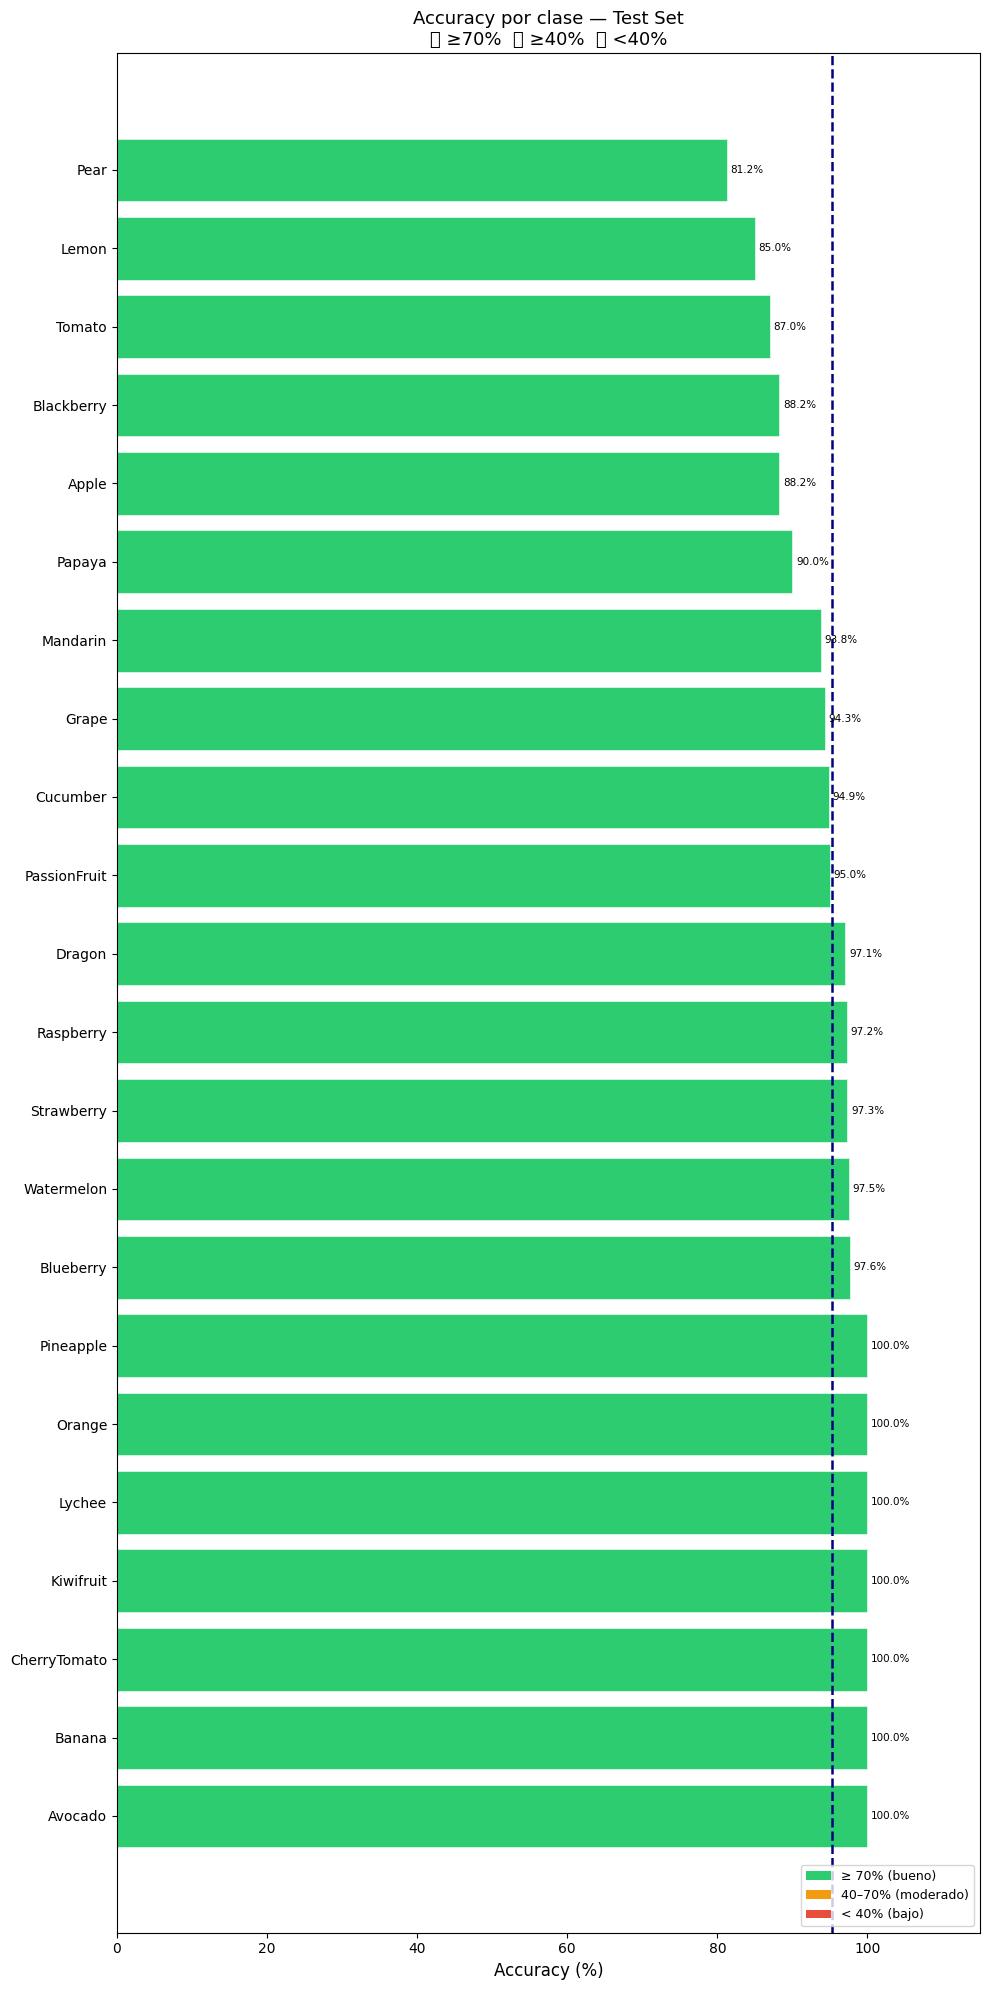

In [ ]:
per_class = {}
for lbl in sorted(set(all_true.tolist())):
    mask = (all_true == lbl)
    if mask.sum() > 0:
        per_class[fused_classes[lbl]] = float((all_preds[mask] == lbl).mean())

sorted_acc = sorted(per_class.items(), key=lambda x: x[1], reverse=True)
names_all  = [x[0] for x in sorted_acc]
vals_all   = [x[1] * 100 for x in sorted_acc]
colors     = ['#2ecc71' if v >= 70 else '#f39c12' if v >= 40 else '#e74c3c' for v in vals_all]

fig, ax = plt.subplots(figsize=(10, 20))
ax.barh(names_all, vals_all, color=colors, edgecolor='white', linewidth=0.4)
ax.axvline(top1 * 100, color='navy', linestyle='--', linewidth=1.8,
           label=f'Media global: {top1*100:.1f}%')
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy por clase — Test Set\n🟢 ≥70%  🟠 ≥40%  🔴 <40%', fontsize=13)
ax.set_xlim(0, 115)
for i, v in enumerate(vals_all):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=7.5)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#2ecc71', label='≥ 70% (bueno)'),
    Patch(facecolor='#f39c12', label='40–70% (moderado)'),
    Patch(facecolor='#e74c3c', label='< 40% (bajo)'),
], loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('accuracy_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

### 14.2 Top-10 mejores y peores clases

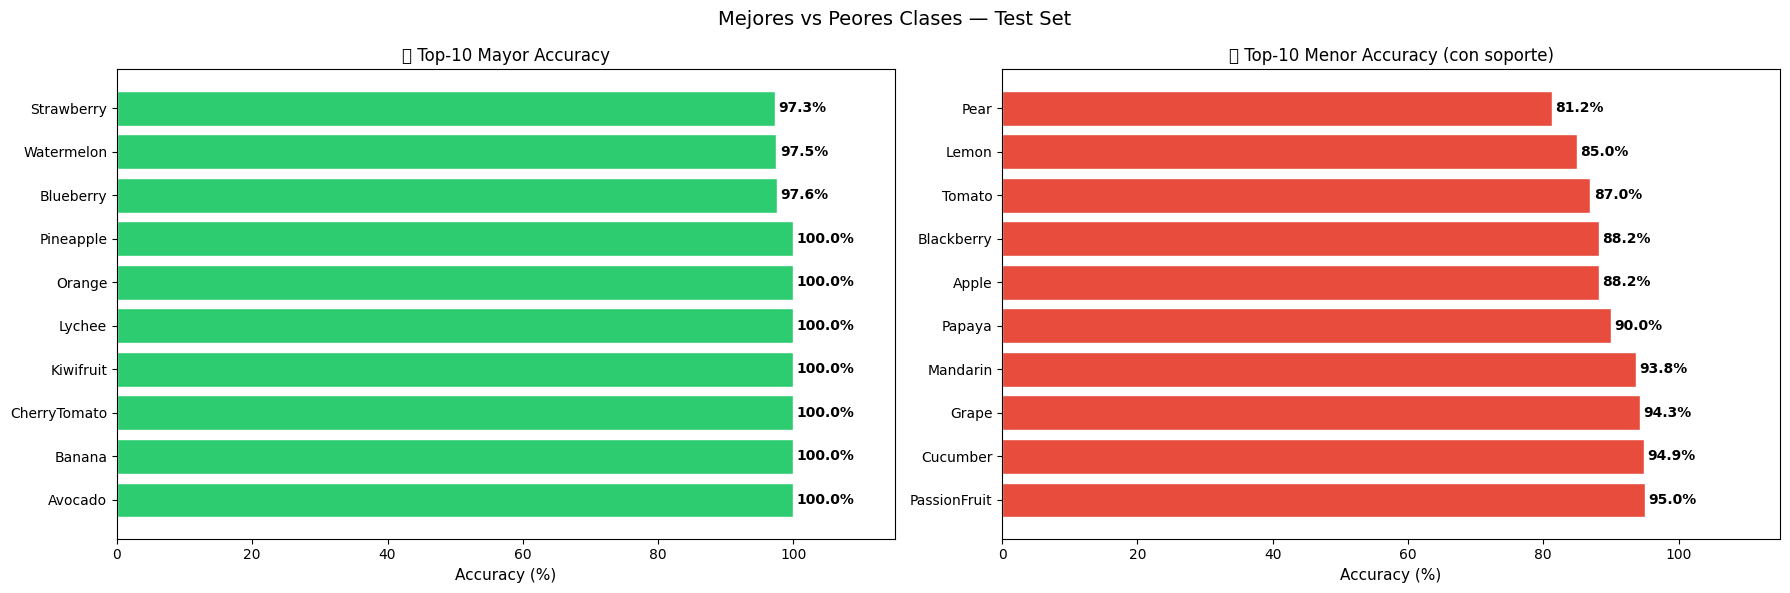

In [ ]:
best10  = sorted_acc[:10]
worst10 = [x for x in sorted_acc if x[1] > 0][-10:]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, data, color, title in zip(
    axes,
    [best10, worst10],
    ['#2ecc71', '#e74c3c'],
    ['✅ Top-10 Mayor Accuracy', '❌ Top-10 Menor Accuracy (con soporte)']
):
    names, vals = zip(*data)
    vals_pct = [v * 100 for v in vals]
    ax.barh(names, vals_pct, color=color, edgecolor='white')
    ax.set_xlabel('Accuracy (%)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, 115)
    for i, v in enumerate(vals_pct):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Mejores vs Peores Clases — Test Set', fontsize=14)
plt.tight_layout()
plt.savefig('top_bottom_clases.png', dpi=150, bbox_inches='tight')
plt.show()

### 14.3 Matriz de confusión normalizada

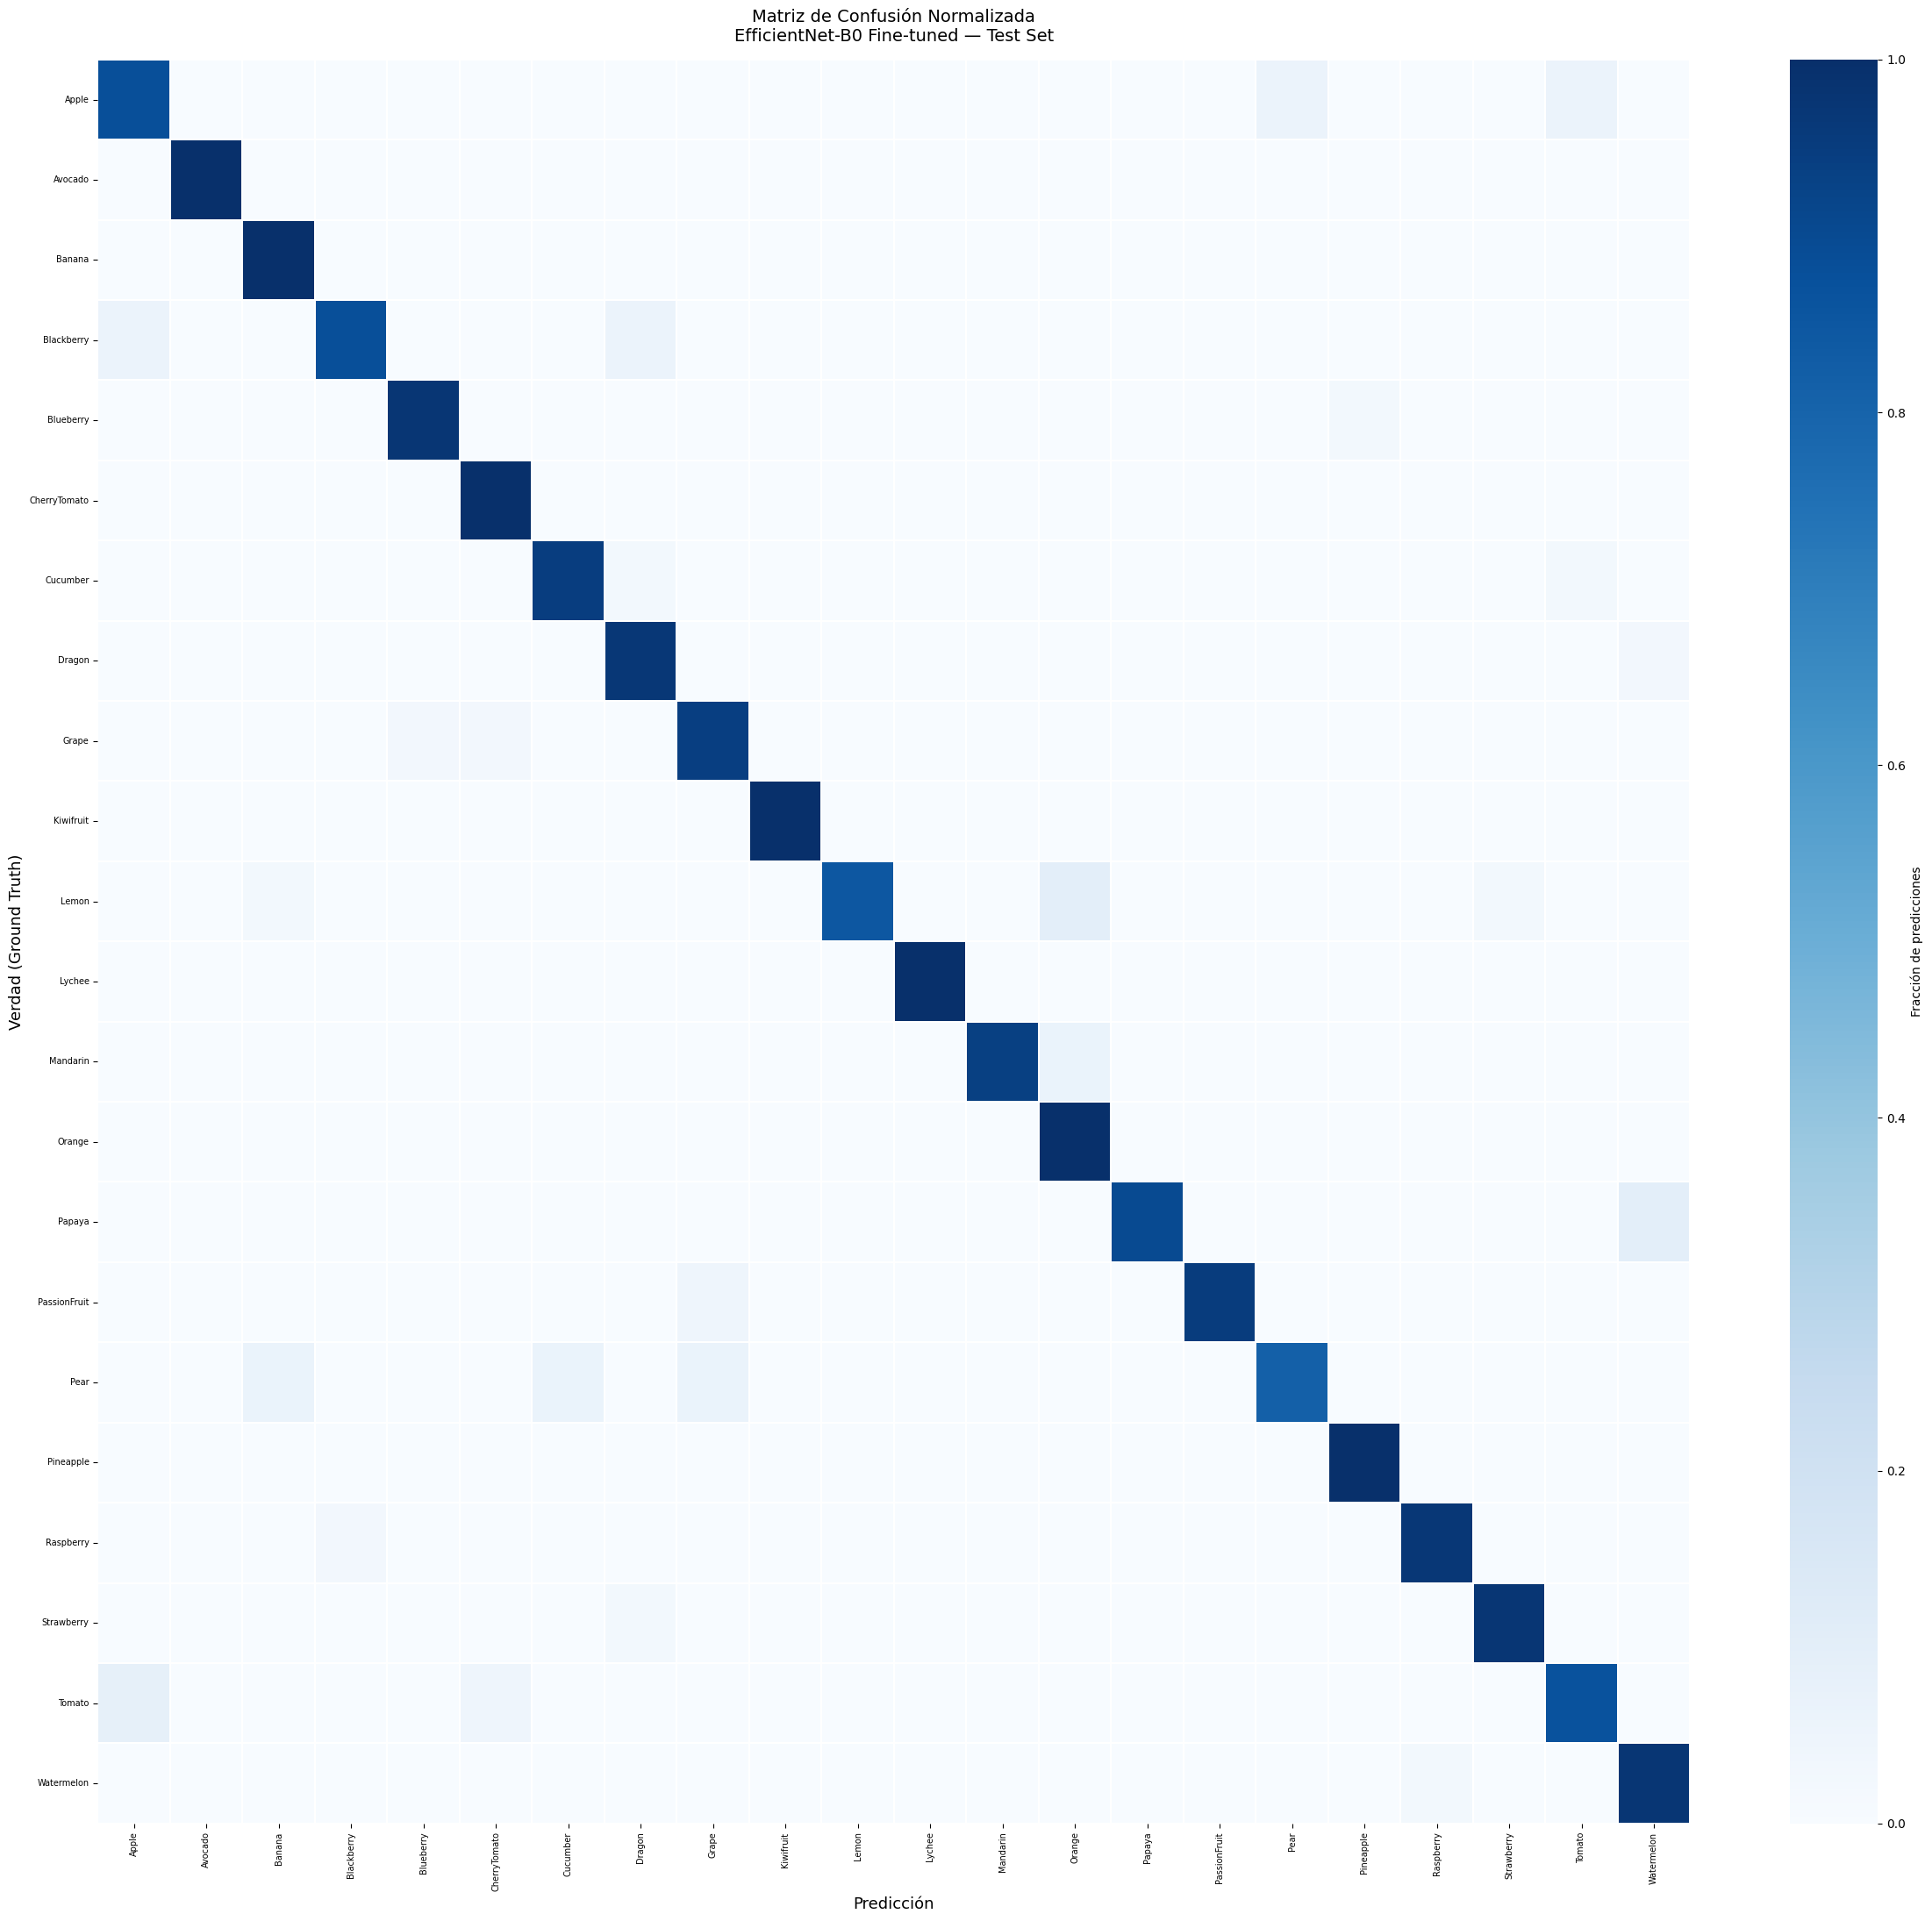

In [ ]:
labels_sup = sorted(set(all_true.tolist()))
names_sup  = [fused_classes[i] for i in labels_sup]

cm      = confusion_matrix(all_true, all_preds, labels=labels_sup)
cm_norm = (cm.astype(float) / cm.sum(axis=1, keepdims=True))
cm_norm = np.nan_to_num(cm_norm)

fig, ax = plt.subplots(figsize=(24, 22))
sns.heatmap(cm_norm, xticklabels=names_sup, yticklabels=names_sup,
            cmap='Blues', vmin=0, vmax=1, linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Fracción de predicciones'})
ax.set_xlabel('Predicción', fontsize=13)
ax.set_ylabel('Verdad (Ground Truth)', fontsize=13)
ax.set_title('Matriz de Confusión Normalizada\nEfficientNet-B0 Fine-tuned — Test Set',
             fontsize=14, pad=15)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 14.4 Distribución de confianza

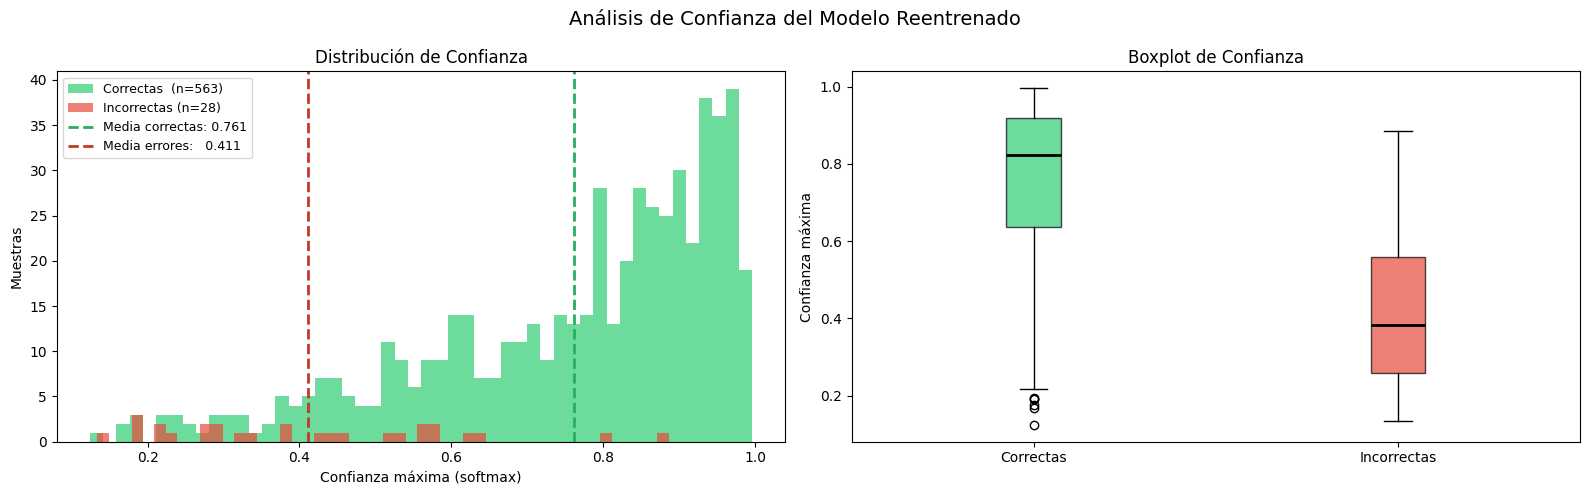

In [ ]:
max_probs    = all_probs.max(axis=1)
correct_mask = (all_preds == all_true)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(max_probs[correct_mask],  bins=50, alpha=0.7, color='#2ecc71',
             label=f'Correctas  (n={correct_mask.sum():,})')
axes[0].hist(max_probs[~correct_mask], bins=50, alpha=0.7, color='#e74c3c',
             label=f'Incorrectas (n={(~correct_mask).sum():,})')
axes[0].axvline(conf_ok,  color='#27ae60', linestyle='--', lw=2,
                label=f'Media correctas: {conf_ok:.3f}')
axes[0].axvline(conf_err, color='#c0392b', linestyle='--', lw=2,
                label=f'Media errores:   {conf_err:.3f}')
axes[0].set_xlabel('Confianza máxima (softmax)')
axes[0].set_ylabel('Muestras')
axes[0].set_title('Distribución de Confianza')
axes[0].legend(fontsize=9)

bp = axes[1].boxplot([max_probs[correct_mask], max_probs[~correct_mask]],
                     labels=['Correctas', 'Incorrectas'], patch_artist=True)
bp['boxes'][0].set(facecolor='#2ecc71', alpha=0.7)
bp['boxes'][1].set(facecolor='#e74c3c', alpha=0.7)
for m in bp['medians']:
    m.set(color='black', linewidth=2)
axes[1].set_ylabel('Confianza máxima')
axes[1].set_title('Boxplot de Confianza')

plt.suptitle('Análisis de Confianza del Modelo Reentrenado', fontsize=14)
plt.tight_layout()
plt.savefig('confianza.png', dpi=150, bbox_inches='tight')
plt.show()

### 14.5 Ejemplos visuales: aciertos y errores

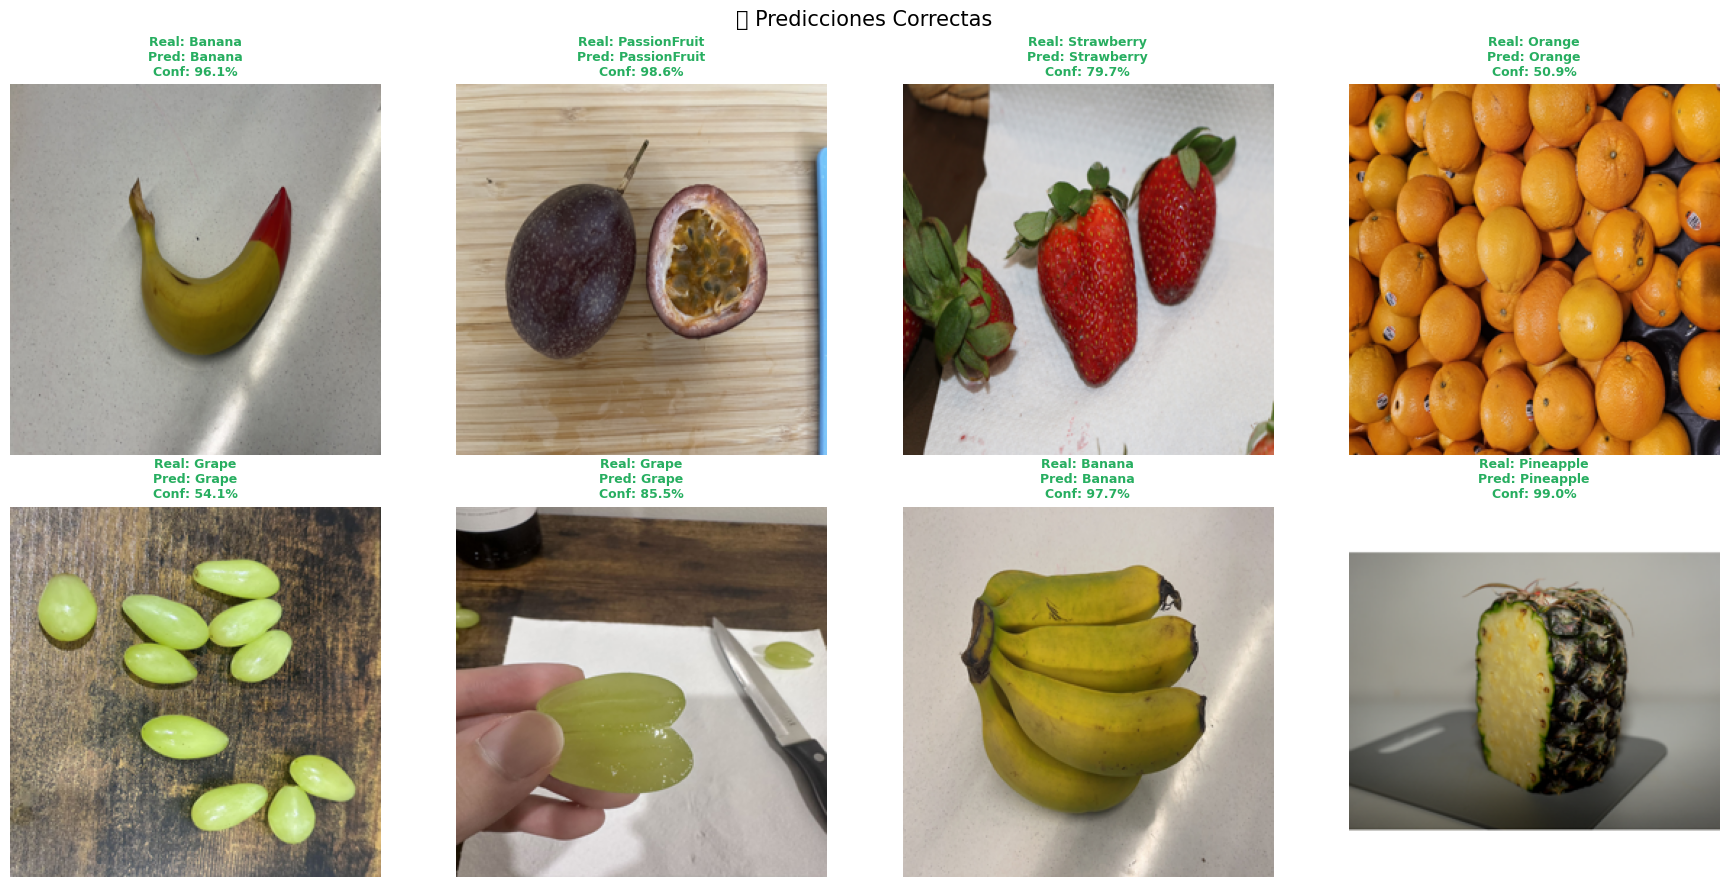

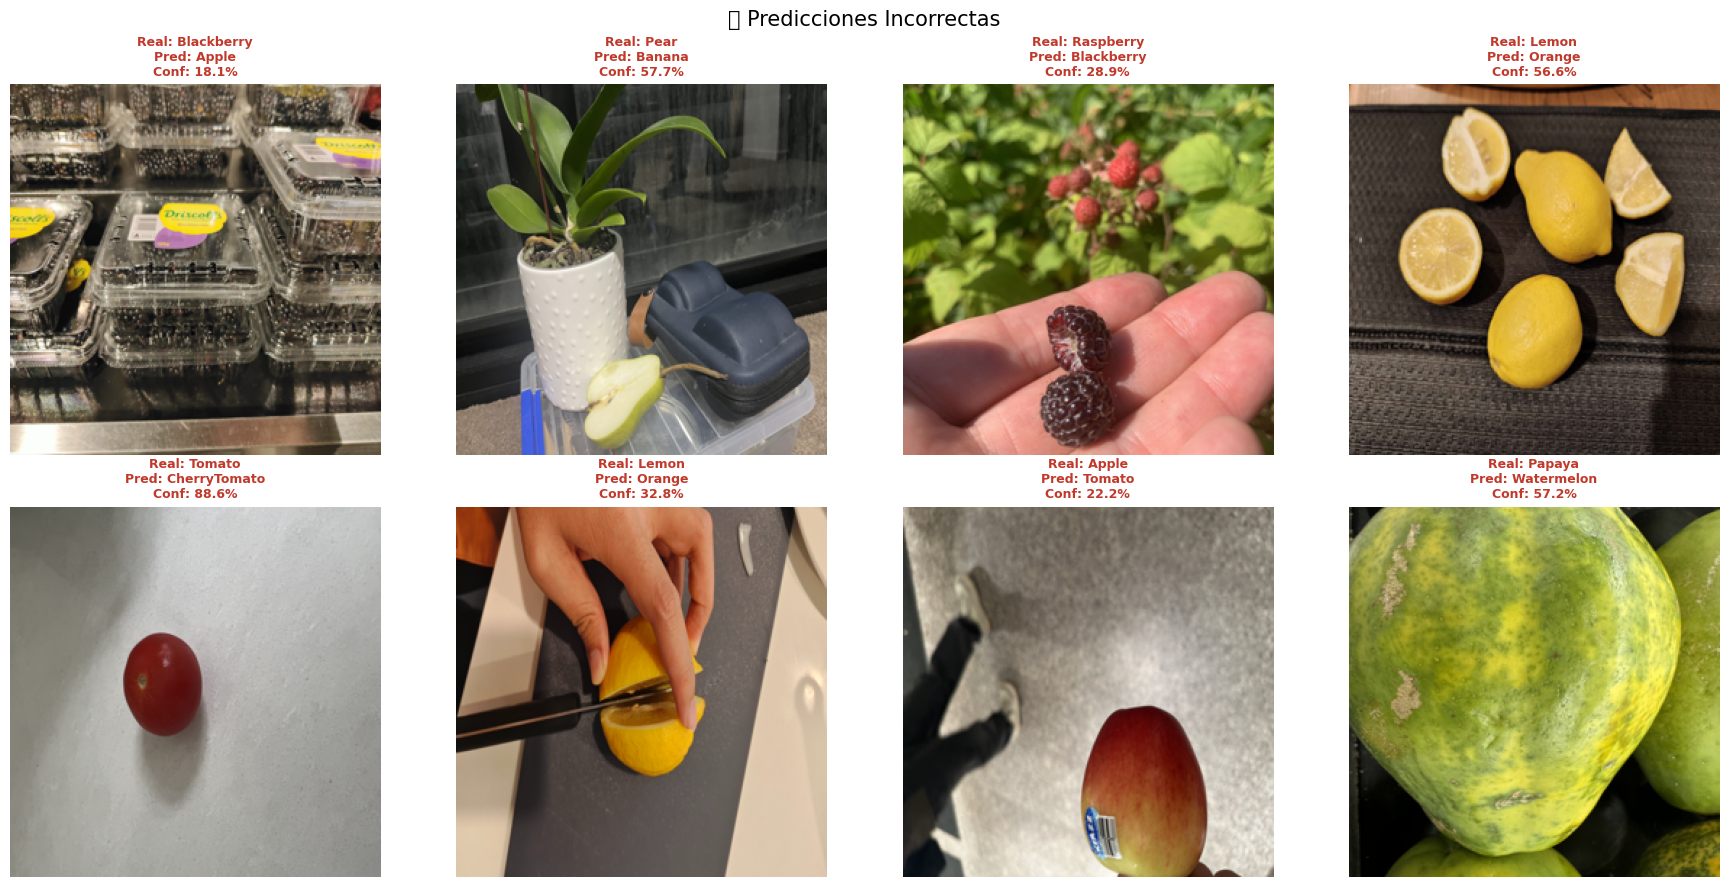

In [ ]:
def show_samples(hf_dataset, label_map_inv, all_true, all_preds, all_probs,
                 fused_classes, correct=True, n=8, seed=42):
    rng  = np.random.default_rng(seed)
    mask = (all_preds == all_true) if correct else (all_preds != all_true)
    pool = np.where(mask)[0]
    idxs = rng.choice(pool, size=min(n, len(pool)), replace=False)

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle('✅ Predicciones Correctas' if correct else '❌ Predicciones Incorrectas',
                 fontsize=15)
    color = '#27ae60' if correct else '#c0392b'

    for ax, si in zip(axes.flatten(), idxs):
        ex       = hf_dataset[int(si)]
        img      = ex['image'].convert('RGB')
        true_lbl = fused_classes[all_true[si]]
        pred_lbl = fused_classes[all_preds[si]]
        conf     = all_probs[si].max()
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'Real: {true_lbl}\nPred: {pred_lbl}\nConf: {conf:.1%}',
                     fontsize=9, color=color, fontweight='bold')

    plt.tight_layout()
    fname = 'ejemplos_correctos.png' if correct else 'ejemplos_incorrectos.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()

show_samples(test_hf, orig_idx_to_fused_idx, all_true, all_preds,
             all_probs, fused_classes, correct=True)
show_samples(test_hf, orig_idx_to_fused_idx, all_true, all_preds,
             all_probs, fused_classes, correct=False)

## 15. Guardar modelo y configuración

In [ ]:
# Guardar pesos del modelo
torch.save(model.state_dict(), '/content/efficientnet_b0_fruits360_finetuned.pth')

# Guardar configuración compatible con el modelo original
model_config = {
    'num_labels': NUM_CLASSES,
    'id2label'  : {str(i): c for i, c in enumerate(fused_classes)},
    'label2id'  : {c: str(i) for i, c in enumerate(fused_classes)},
    'architecture': 'efficientnet_b0',
    'img_size'    : IMG_SIZE,
    'top1_acc'    : round(top1, 4),
    'top5_acc'    : round(top5, 4),
}
with open('/content/config_finetuned.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print('Archivos guardados:')
print('  /content/efficientnet_b0_fruits360_finetuned.pth  ← pesos del modelo')
print('  /content/config_finetuned.json                    ← configuración')
print(f'\nTop-1 Accuracy final: {top1 * 100:.2f}%')
print(f'Top-5 Accuracy final: {top5 * 100:.2f}%')

Archivos guardados:
  /content/efficientnet_b0_fruits360_finetuned.pth  ← pesos del modelo
  /content/config_finetuned.json                    ← configuración

Top-1 Accuracy final: 95.26%
Top-5 Accuracy final: 99.66%
